# Q1 Part 4 — Parameter studies  (spec A.4)
- ε = {0.01, 0.1, 0.2} at fixed M∞
- M∞ = {0.2, 0.5, 0.85} at fixed ε
- Attempt M∞ = 2 and discuss why it fails.

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from utils_final import solve_potential, compute_uv, Usurf_on_y0, dYb_dx

def hist_arrays(info):
    h = info["hist"]
    return (np.array([r["it"]  for r in h]),
            np.array([r["res"] for r in h]),
            np.array([r["upd"] for r in h]),
            np.array([r["time"] for r in h]))

TOL_RES = 1e-5
TOL_UPD = 1e-5
MAX_ITER = 30000
CHECK = 200

# Slightly larger domain to be safe at higher M
q, s, r = 6.0, 6.0, 6.0
Nx, Ny = 201, 101
omega_use = 1.85  # near-optimal for this grid

In [124]:
def run_case(eps, M, label=None, omega=None):
    """Solve and return a results dict."""
    w = omega if omega else omega_use
    phi, x, y, info = solve_potential(
        eps=eps, M=M, q=q, s=s, r=r, Nx=Nx, Ny=Ny,
        method="sor", omega=w,
        tol_res=TOL_RES, tol_upd=TOL_UPD,
        max_iter=MAX_ITER, check_every=CHECK, verbose=False,
    )
    u, v = compute_uv(phi, info["dx"], info["dy"])
    mask = (x >= -1.0) & (x <= 1.0)
    tag = label or f"ε={eps}, M={M}"
    status = "✓" if info["converged"] else f"✗ ({info['iters']} its)"
    print(f"  {tag:20s}  {status}  iters={info['iters']}  time={info['seconds']:.1f}s")
    return {"phi": phi, "x": x, "y": y, "info": info,
            "u": u, "v": v, "mask_bump": mask}

In [126]:
# ═══════════════════════════════════════
# (a) ε sweep at fixed M∞ = 0.2
# ═══════════════════════════════════════
eps_list = [0.01, 0.1, 0.2]
M_fixed = 0.2
results_eps = {}
for eps_i in eps_list:
    results_eps[eps_i] = run_case(eps_i, M_fixed, label=f"ε={eps_i}, M∞={M_fixed}")

  ε=0.01, M∞=0.2        ✓  iters=3800  time=1.0s
  ε=0.1, M∞=0.2         ✓  iters=5600  time=1.5s
  ε=0.2, M∞=0.2         ✓  iters=6200  time=1.6s


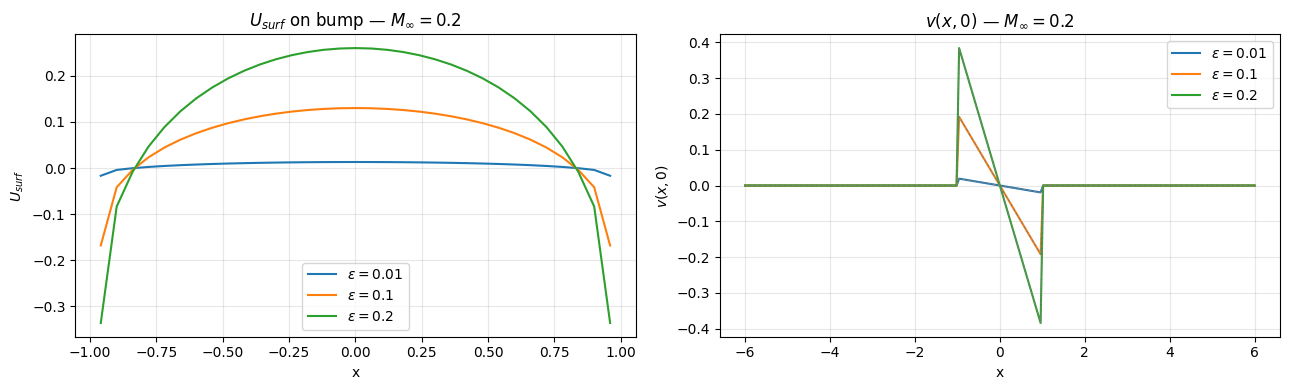

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Usurf on bump
for eps_i, res in results_eps.items():
    m = res["mask_bump"]; x = res["x"]
    axes[0].plot(x[m], res["u"][m, 0], label=fr"$\varepsilon={eps_i}$")
axes[0].set_xlabel("x"); axes[0].set_ylabel(r"$U_{surf}$")
axes[0].set_title(fr"$U_{{surf}}$ on bump — $M_\infty = {M_fixed}$")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# v along y = 0
for eps_i, res in results_eps.items():
    x = res["x"]
    axes[1].plot(x, res["v"][:, 0], label=fr"$\varepsilon={eps_i}$")
    # overlay exact BC
    g = dYb_dx(x, eps_i)
    axes[1].plot(x, g, "--", color="gray", lw=0.7)
axes[1].set_xlabel("x"); axes[1].set_ylabel(r"$v(x,0)$")
axes[1].set_title(fr"$v(x,0)$ — $M_\infty = {M_fixed}$")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [130]:
# ═══════════════════════════════════════
# (b) M∞ sweep at fixed ε = 0.1
# ═══════════════════════════════════════
eps_fixed = 0.1
M_list = [0.2, 0.5, 0.85]
results_M = {}
for M_i in M_list:
    results_M[M_i] = run_case(eps_fixed, M_i, label=f"ε={eps_fixed}, M∞={M_i}")

  ε=0.1, M∞=0.2         ✓  iters=5600  time=1.5s
  ε=0.1, M∞=0.5         ✓  iters=6400  time=1.7s
  ε=0.1, M∞=0.85        ✓  iters=12800  time=3.4s


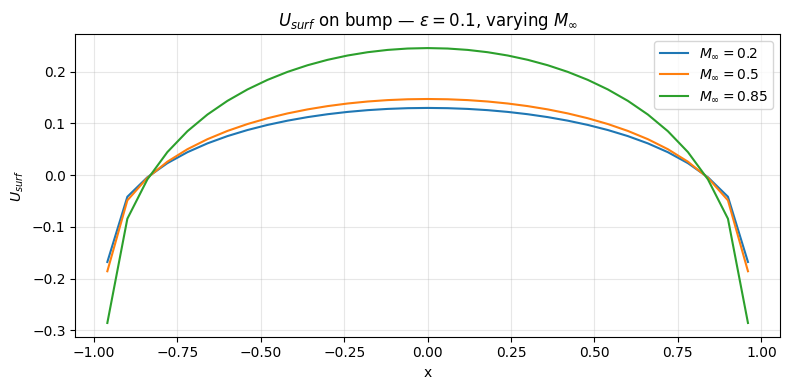

In [131]:
fig, ax = plt.subplots(figsize=(8, 4))
for M_i, res in results_M.items():
    m = res["mask_bump"]; x = res["x"]
    ax.plot(x[m], res["u"][m, 0], label=fr"$M_\infty={M_i}$")
ax.set_xlabel("x"); ax.set_ylabel(r"$U_{surf}$")
ax.set_title(fr"$U_{{surf}}$ on bump — $\varepsilon={eps_fixed}$, varying $M_\infty$")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

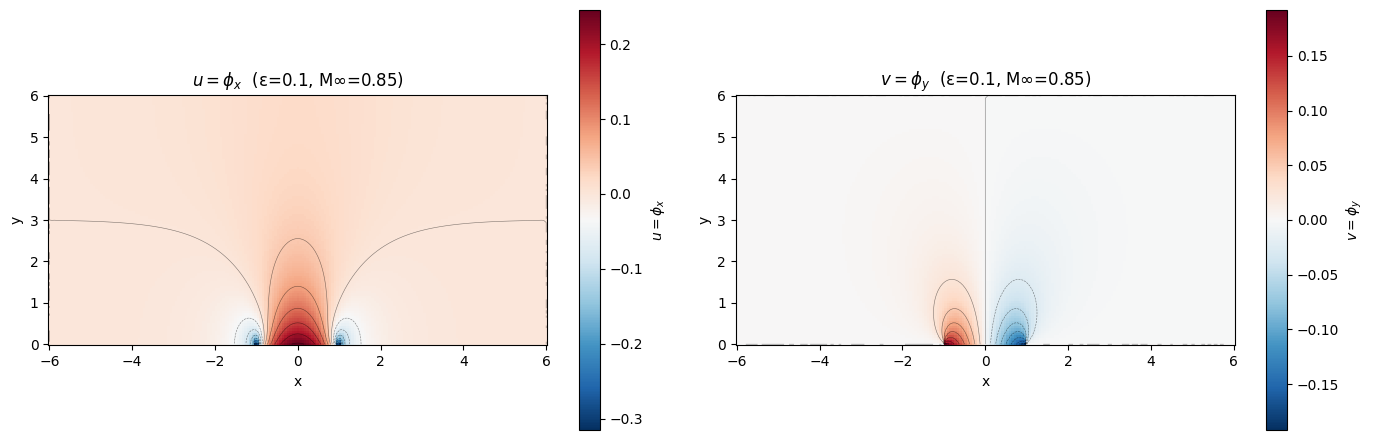

In [132]:
# Field colour plots for M∞ = 0.85  (strongest compressibility effect)
res85 = results_M[0.85]
X, Y = np.meshgrid(res85["x"], np.linspace(0, r, Ny), indexing="ij")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, field, lab in zip(axes, [res85["u"], res85["v"]],
                          [r"$u=\phi_x$", r"$v=\phi_y$"]):
    pcm = ax.pcolormesh(X, Y, field, shading="auto", cmap="RdBu_r")
    ax.contour(X, Y, field, levels=15, colors="k", linewidths=0.4, alpha=0.5)
    fig.colorbar(pcm, ax=ax, label=lab)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"{lab}  (ε={eps_fixed}, M∞=0.85)")
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

In [133]:
# ═══════════════════════════════════════
# (c) Attempt M∞ = 2
# ═══════════════════════════════════════
# Physical note:  (1 - M²) = 1 - 4 = -3
# The coefficient of φ_xx becomes NEGATIVE, so the PDE switches from
# elliptic (Laplace-like) to HYPERBOLIC (wave-like).
# Central-difference iterative solvers (Jacobi/GS/SOR) are designed for
# elliptic problems and will NOT converge when the equation is hyperbolic.
# The stencil eigenvalues leave the unit circle and the iterations diverge.

print("(1 - M²) for M∞=2:", 1.0 - 2.0**2, "  → equation is HYPERBOLIC")
print("Central-difference Jacobi/GS/SOR are only stable for elliptic PDEs.")
print("Expected behaviour: divergence or non-convergence.\n")

res2 = run_case(eps_fixed, 2.0, label="ε=0.1, M∞=2.0")

(1 - M²) for M∞=2: -3.0   → equation is HYPERBOLIC
Central-difference Jacobi/GS/SOR are only stable for elliptic PDEs.
Expected behaviour: divergence or non-convergence.



/Users/yeonakim/Documents/CPDEs/CW2/Q1/utils_final.py:89: RuntimeWarning: overflow encountered in multiply
  
/Users/yeonakim/Documents/CPDEs/CW2/Q1/utils_final.py:89: RuntimeWarning: overflow encountered in add
  
/Users/yeonakim/Documents/CPDEs/CW2/Q1/utils_final.py:92: RuntimeWarning: invalid value encountered in add
  """Infinity-norm update size (interior only)."""
/Users/yeonakim/Documents/CPDEs/CW2/Q1/utils_final.py:36: RuntimeWarning: overflow encountered in subtract
  
/Users/yeonakim/Documents/CPDEs/CW2/Q1/utils_final.py:90: RuntimeWarning: invalid value encountered in add
  
/Users/yeonakim/Documents/CPDEs/CW2/Q1/utils_final.py:89: RuntimeWarning: invalid value encountered in add
  
/Users/yeonakim/Documents/CPDEs/CW2/Q1/utils_final.py:36: RuntimeWarning: overflow encountered in multiply
  
/Users/yeonakim/Documents/CPDEs/CW2/Q1/utils_final.py:39: RuntimeWarning: overflow encountered in multiply
  def step_jacobi(phi: np.ndarray, M: float, dx: float, dy: float) -> np.ndarray

  ε=0.1, M∞=2.0         ✗ (30000 its)  iters=30000  time=8.5s


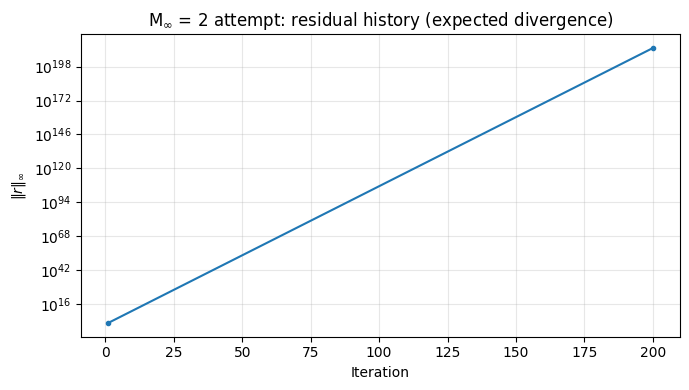


Result: converged = False
Final residual = nan  (initial = 1.586e+01)

Conclusion: As expected, the solver diverges because the PDE is
hyperbolic for M∞ > 1.  A different numerical approach is needed
(e.g. upwind differencing, time-marching, or the Murman-Cole scheme).


In [134]:
# Show diverging residual history
it, res, upd, t = hist_arrays(res2["info"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(it, res, "o-", ms=3)
ax.set_xlabel("Iteration"); ax.set_ylabel(r"$\|r\|_\infty$")
ax.set_title(r"M$_\infty$ = 2 attempt: residual history (expected divergence)")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nResult: converged = {res2['info']['converged']}")
print(f"Final residual = {res[-1]:.3e}  (initial = {res[0]:.3e})")
print("\nConclusion: As expected, the solver diverges because the PDE is")
print("hyperbolic for M∞ > 1.  A different numerical approach is needed")
print("(e.g. upwind differencing, time-marching, or the Murman-Cole scheme).")

In [135]:
# ═══════════════════════════════════════
# (d) Summary table
# ═══════════════════════════════════════
print(f"{'Case':30s} {'Conv':5s} {'Iters':>7s} {'Time(s)':>8s}")
print("-" * 55)
for eps_i, res in results_eps.items():
    info = res["info"]
    print(f"ε={eps_i:<5}, M∞={M_fixed}              {'Y' if info['converged'] else 'N':5s} {info['iters']:7d} {info['seconds']:8.1f}")
for M_i, res in results_M.items():
    info = res["info"]
    print(f"ε={eps_fixed}, M∞={M_i:<5}              {'Y' if info['converged'] else 'N':5s} {info['iters']:7d} {info['seconds']:8.1f}")
info2 = res2["info"]
print(f"ε={eps_fixed}, M∞=2.0 (hyperbolic!)   {'Y' if info2['converged'] else 'N':5s} {info2['iters']:7d} {info2['seconds']:8.1f}")

Case                           Conv    Iters  Time(s)
-------------------------------------------------------
ε=0.01 , M∞=0.2              Y        3800      1.0
ε=0.1  , M∞=0.2              Y        5600      1.5
ε=0.2  , M∞=0.2              Y        6200      1.6
ε=0.1, M∞=0.2                Y        5600      1.5
ε=0.1, M∞=0.5                Y        6400      1.7
ε=0.1, M∞=0.85               Y       12800      3.4
ε=0.1, M∞=2.0 (hyperbolic!)   N       30000      8.5
